# EHWGesture Benchmark: EvT-OG vs TimeSformer

This notebook builds a benchmark comparison between the two pipelines intended for this project:

- **EvT-OG**: event-native transformer working on sparse event-frame chunks.
- **TimeSformer**: video transformer trained on RGB clips.

The dataset used is EHWGesture:

- TODO talk aboit the data

The notebook is intended to answer these questions:

- How do the two models compare on **top-1** and **top-5** accuracy?
- What happens on **train** versus **validation**?
- Which classes are confused on the shared test split?
- What do the validation curves look like?
- How do parameters, FLOPs, latency, activated patches, and GPU memory compare where measurable?

## 1. Paths and experiment scope

In [2]:
from __future__ import annotations

import contextlib
import io
import json
import os
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import confusion_matrix

/home/ppfsa/miniconda3/envs/tese_ehw_py37/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ROOT = Path('/home/ppfsa/TESE')
DEV_ROOT = ROOT / 'dev'
EVT_ROOT = DEV_ROOT / 'EvT-OG'
TS_ROOT = DEV_ROOT / 'TimeSformer'

EVT_MODEL_DIR = EVT_ROOT / 'pretrained_models' / 'ehwgesture_finetune_earlystop' / '0415_1631_model_1'
EVT_METRICS_CSV = EVT_MODEL_DIR / 'train_log' / 'final_version' / 'metrics.csv'
if not EVT_METRICS_CSV.exists():
    EVT_METRICS_CSV = EVT_MODEL_DIR / 'train_log' / 'final_version' / 'metrics.csv'
EVT_STATS_JSON = EVT_MODEL_DIR / 'stats_test_ehwgesture.json'

TS_OUTPUT_DIR = TS_ROOT / 'outputs' / 'ehwgesture'

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
RUN_EVT_COMPLEXITY = True

CLASS_NAMES = ['FT', 'OC', 'PS', 'NOSE', 'TR']
DISPLAY_CLASS_NAMES = [
    'Finger tapping',
    'Hand opening/closing',
    'Pronation-supination',
    'Finger-to-nose',
    'Tremor arm extension',
]
CLASS_NAME_MAP = dict(zip(CLASS_NAMES, DISPLAY_CLASS_NAMES))

print('Device:', DEVICE)
print('EvT model dir:', EVT_MODEL_DIR)
print('EvT metrics csv:', EVT_METRICS_CSV)
print('TimeSformer output dir (pending):', TS_OUTPUT_DIR)
print('EvT stats json exists:', EVT_STATS_JSON.exists())

# TODO: Timesformer part


Device: cuda:0
EvT model dir: /home/ppfsa/TESE/dev/EvT-OG/pretrained_models/ehwgesture_finetune_earlystop/0415_1631_model_1
EvT metrics csv: /home/ppfsa/TESE/dev/EvT-OG/pretrained_models/ehwgesture_finetune_earlystop/0415_1631_model_1/train_log/final_version/metrics.csv
TimeSformer output dir (pending): /home/ppfsa/TESE/dev/TimeSformer/outputs/ehwgesture
EvT stats json exists: True


## 2. Artifact inspection and run selection

In [8]:
def text_line_count(path: Path) -> int:
    if not path.exists():
        return 0
    return sum(1 for line in path.read_text().splitlines() if line.strip())


RAW_EHW_SPLITS_DIR = DEV_ROOT / 'datasets' / 'raw' / 'EHWGesture'
RAW_EHW_AEDAT4_SIZE_GB = sum(path.stat().st_size for path in (RAW_EHW_SPLITS_DIR / 'DataEvent').rglob('*.aedat4')) / (1024 ** 3)
RAW_EHW_MP4_SIZE_GB = sum(path.stat().st_size for path in (RAW_EHW_SPLITS_DIR / 'DataKinects').rglob('*.mp4')) / (1024 ** 3)

split_summary = pd.DataFrame([
    {'split': 'train', 'events': text_line_count(RAW_EHW_SPLITS_DIR / 'trials_to_train.txt')},
    {'split': 'val', 'events': text_line_count(RAW_EHW_SPLITS_DIR / 'trials_to_val.txt')},
    {'split': 'test', 'events': text_line_count(RAW_EHW_SPLITS_DIR / 'trials_to_test.txt')},
])

print('Samples Used for EvT-OG on EHWGesture (.aedat4 files)')
display(split_summary)
print(f'Size: {RAW_EHW_AEDAT4_SIZE_GB:.3f} GB\n')

print('Samples Used for Timesformer on EHWGesture (.mp4 files)')
print(f'Size: {RAW_EHW_MP4_SIZE_GB:.3f} GB')
# TODO: Timesformer part


Samples Used for EvT-OG on EHWGesture (.aedat4 files)


,split,events
0,train,698
1,val,176
2,test,220


Size: 41.851 GB

Samples Used for Timesformer on EHWGesture (.mp4 files)
Size: 134.043 GB


## 3. Load training curves

This cell converts the saved EvT and TimeSformer logs into comparable tables.

- For **EvT-OG**, the source is `metrics.csv`.
- For **TimeSformer**, TODO

Trainning Metrics for EvT-OG on EHWGesture


,epoch,lr-AdamW,train_loss_clf,train_acc,train_acc_top5,train_loss_total,val_loss_clf,val_acc,val_acc_top5,val_loss_total
0,1,0.000010,1.700000,0.190000,1.0,1.700000,1.680000,0.255000,1.0,1.680000
1,2,0.000032,1.560000,0.291000,1.0,1.560000,1.550000,0.366000,1.0,1.550000
2,3,0.000056,1.360000,0.440000,1.0,1.360000,1.400470,0.342220,1.0,1.400470
3,4,0.000080,1.215738,0.502907,1.0,1.215738,1.195517,0.447778,1.0,1.195517
4,5,0.000110,1.088450,0.570833,1.0,1.088450,1.049350,0.651111,1.0,1.049350
...,...,...,...,...,...,...,...,...,...,...
73,74,0.000028,0.180644,0.931395,1.0,0.180644,0.189658,0.933333,1.0,0.189658
74,75,0.000020,0.174909,0.946027,1.0,0.174909,0.192149,0.938889,1.0,0.192149
75,76,0.000013,0.173596,0.934496,1.0,0.173596,0.192503,0.938889,1.0,0.192503
76,77,0.000007,0.181730,0.944670,1.0,0.181730,0.193307,0.938889,1.0,0.193307


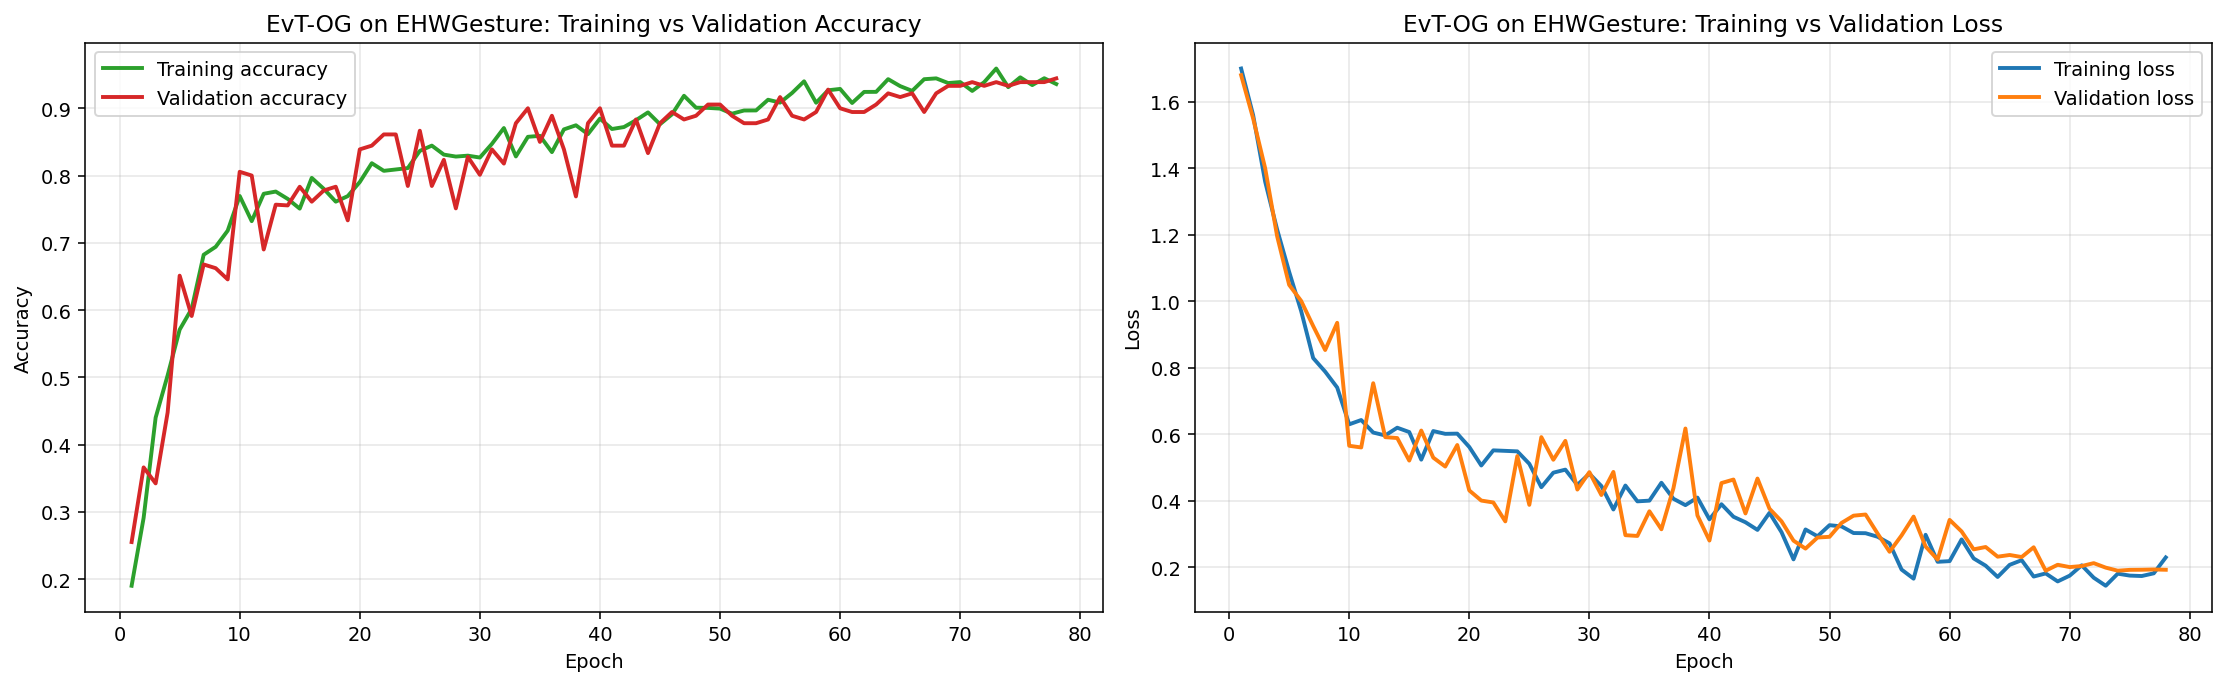

Trainning Metrics for Timesformer on EHWGesture


In [4]:
def load_evt_logs() -> pd.DataFrame:
    logs = pd.read_csv(EVT_METRICS_CSV)
    for i, row in logs[logs.epoch.isna()].iterrows():
        candidate = logs[(~logs.epoch.isna()) & (logs.step >= int(row.step))].epoch.min()
        logs.loc[i, 'epoch'] = candidate
    logs['epoch'] = logs['epoch'].astype(int) + 1
    return logs


def build_evt_epoch_metrics(logs: pd.DataFrame) -> pd.DataFrame:
    epoch_metrics = logs.groupby('epoch', as_index=False).first()
    metric_cols = [
        'epoch', 'lr-AdamW', 'train_loss_clf', 'train_acc', 'train_acc_top5', 'train_loss_total',
        'val_loss_clf', 'val_acc', 'val_acc_top5', 'val_loss_total'
    ]
    metric_cols = [c for c in metric_cols if c in epoch_metrics.columns]
    return epoch_metrics[metric_cols].copy()


evt_logs = load_evt_logs()
evt_epoch_metrics = build_evt_epoch_metrics(evt_logs)

print('Trainning Metrics for EvT-OG on EHWGesture')
display(evt_epoch_metrics)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=140)
axes[0].plot(evt_epoch_metrics['epoch'], evt_epoch_metrics['train_acc'], label='Training accuracy', color='tab:green', linewidth=2)
axes[0].plot(evt_epoch_metrics['epoch'], evt_epoch_metrics['val_acc'], label='Validation accuracy', color='tab:red', linewidth=2)
axes[0].set_title('EvT-OG on EHWGesture: Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].plot(evt_epoch_metrics['epoch'], evt_epoch_metrics['train_loss_total'], label='Training loss', color='tab:blue', linewidth=2)
axes[1].plot(evt_epoch_metrics['epoch'], evt_epoch_metrics['val_loss_total'], label='Validation loss', color='tab:orange', linewidth=2)
axes[1].set_title('EvT-OG on EHWGesture: Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

print('Trainning Metrics for Timesformer on EHWGesture')
# TODO: Timesformer part


## 4. Evaluation helpers

This is the core benchmark cell. It defines post-hoc evaluation functions for both models on **test** splits.

For each model and split, the notebook computes:

- top-1 accuracy;
- top-5 accuracy;
- normalized confusion matrix;
- inference latency;
- peak GPU memory, if running on CUDA.

For EvT-OG, the notebook also measures average activated patches and average FLOPs over active windows, because those metrics are already supported by the current original codebase.


In [5]:
def _push_path(path: Path):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)


def evaluate_evt_split(split: str, device: str = DEVICE, run_complexity: bool = False) -> dict:
    cwd = Path.cwd()
    os.chdir(EVT_ROOT)
    _push_path(EVT_ROOT)
    try:
        from trainer_ehwgesture import EvNetModel, get_best_weights
        from data_generation_ehwgesture import Event_DataModule

        all_params = json.loads((EVT_MODEL_DIR / 'all_params.json').read_text())
        path_weights = get_best_weights(str(EVT_MODEL_DIR), 'val_acc', 'max')
        model = EvNetModel.load_from_checkpoint(
            path_weights,
            map_location=torch.device('cpu'),
            **all_params,
        ).eval().to(device)

        data_params = dict(all_params['data_params'])
        data_params['batch_size'] = 1
        data_params['pin_memory'] = False
        data_params['sample_repetitions'] = 1
        dm = Event_DataModule(**data_params)
        dl = dm.test_dataloader() if split == 'test' else dm.val_dataloader()

        y_true, y_pred, top5_hits = [], [], []
        times_ms = []
        complexity_flops = []
        complexity_patches = []
        peak_gpu_mem_gb = None

        if device.startswith('cuda') and torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(device)

        for polarity, pixels, labels in dl:
            if polarity is None:
                continue
            polarity, pixels, labels = polarity.to(device), pixels.to(device), labels.to(device)
            start_evt = torch.cuda.Event(enable_timing=True) if device.startswith('cuda') and torch.cuda.is_available() else None
            end_evt = torch.cuda.Event(enable_timing=True) if start_evt is not None else None

            if start_evt is not None:
                start_evt.record()
            else:
                wall_t0 = time.time()

            with torch.no_grad():
                _, clf_logits = model(polarity, pixels)

            if end_evt is not None:
                end_evt.record()
                torch.cuda.synchronize()
                elapsed_ms = start_evt.elapsed_time(end_evt)
            else:
                elapsed_ms = (time.time() - wall_t0) * 1000.0
            times_ms.append(float(elapsed_ms / max(1, len(polarity))))

            preds = clf_logits.argmax(dim=-1)
            top5 = torch.topk(clf_logits, k=min(5, clf_logits.shape[-1]), dim=-1).indices
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
            top5_hits.extend(top5.eq(labels.unsqueeze(-1)).any(dim=-1).float().cpu().tolist())

            if run_complexity:
                try:
                    from ptflops import get_model_complexity_info
                    for ts in range(len(polarity)):
                        mask = polarity[ts:ts+1].sum(-1).sum(0).sum(0) != 0
                        if mask.sum() == 0:
                            continue
                        pol_t = polarity[ts:ts+1][:, :, mask, :]
                        pix_t = pixels[ts:ts+1][:, :, mask, :]
                        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                            macs, _ = get_model_complexity_info(
                                model.backbone,
                                ({'kv': pol_t, 'pixels': pix_t},),
                                input_constructor=lambda x: x[0],
                                as_strings=False,
                                print_per_layer_stat=False,
                                verbose=False,
                            )
                        complexity_flops.append(float(2 * macs))
                        complexity_patches.append(int(mask.sum().item()))
                except Exception:
                    pass

        if device.startswith('cuda') and torch.cuda.is_available():
            peak_gpu_mem_gb = torch.cuda.max_memory_allocated(device) / (1024 ** 3)

        class_mapping = {i: name for i, name in enumerate(CLASS_NAMES)}
        y_true_cm = [class_mapping[int(i)] for i in y_true]
        y_pred_cm = [class_mapping[int(i)] for i in y_pred]
        labels_cm = CLASS_NAMES
        cm = confusion_matrix(y_true_cm, y_pred_cm, normalize='true', labels=labels_cm)
        df_cm = pd.DataFrame(cm, index=labels_cm, columns=labels_cm)

        return {
            'model': 'EvT-OG',
            'split': split,
            'top1_acc': float(np.mean(np.array(y_true) == np.array(y_pred)) * 100.0),
            'top5_acc': float(np.mean(top5_hits) * 100.0),
            'latency_ms': float(np.mean(times_ms)) if times_ms else None,
            'peak_gpu_mem_gb': None if peak_gpu_mem_gb is None else float(peak_gpu_mem_gb),
            'confusion_matrix': df_cm,
            'params_m': float(sum(p.numel() for p in model.parameters()) / 1_000_000),
            'flops_g': None if not complexity_flops else float(np.mean(complexity_flops) * 1e-9),
            'activated_patches': None if not complexity_patches else float(np.mean(complexity_patches)),
        }
    finally:
        os.chdir(cwd)


def evaluate_timesformer_split(split: str) -> dict:
    return {
        'model': 'TimeSformer',
        'split': split,
        'top1_acc': None,
        'top5_acc': None,
        'latency_ms': None,
        'peak_gpu_mem_gb': None,
        'confusion_matrix': None,
        'params_m': None,
        'flops_g': None,
        'activated_patches': None,
    }


## 5. Run post-hoc test evaluations

This cell executes the actual post-hoc evaluations. It gives the notebook a clean comparison table for the same test split on both models.

In [6]:
evt_test_eval = evaluate_evt_split('test', run_complexity=RUN_EVT_COMPLEXITY)

fair_test_df = pd.DataFrame([
    {
        'Model': evt_test_eval['model'],
        'Split': evt_test_eval['split'],
        'Top-1 acc (%)': evt_test_eval['top1_acc'],
        'Top-5 acc (%)': evt_test_eval['top5_acc'],
    },
])

fair_test_df['Top-1 gap vs best (pp)'] = fair_test_df['Top-1 acc (%)'].max() - fair_test_df['Top-1 acc (%)']
fair_test_df['Top-5 gap vs best (pp)'] = fair_test_df['Top-5 acc (%)'].max() - fair_test_df['Top-5 acc (%)']

print('Post-hoc Test Evaluation Comparison on EHWGesture')
display(fair_test_df)

# TODO: Timesformer part

Post-hoc Test Evaluation Comparison on EHWGesture


,Model,Split,Top-1 acc (%),Top-5 acc (%),Top-1 gap vs best (pp),Top-5 gap vs best (pp)
0,EvT-OG,test,89.090909,100.0,0.0,0.0


## 6. Shared-test confusion matrices

This is where the fair comparison becomes concrete at class level.

Both matrices below are computed on the same test split, so differences here are directly meaningful.

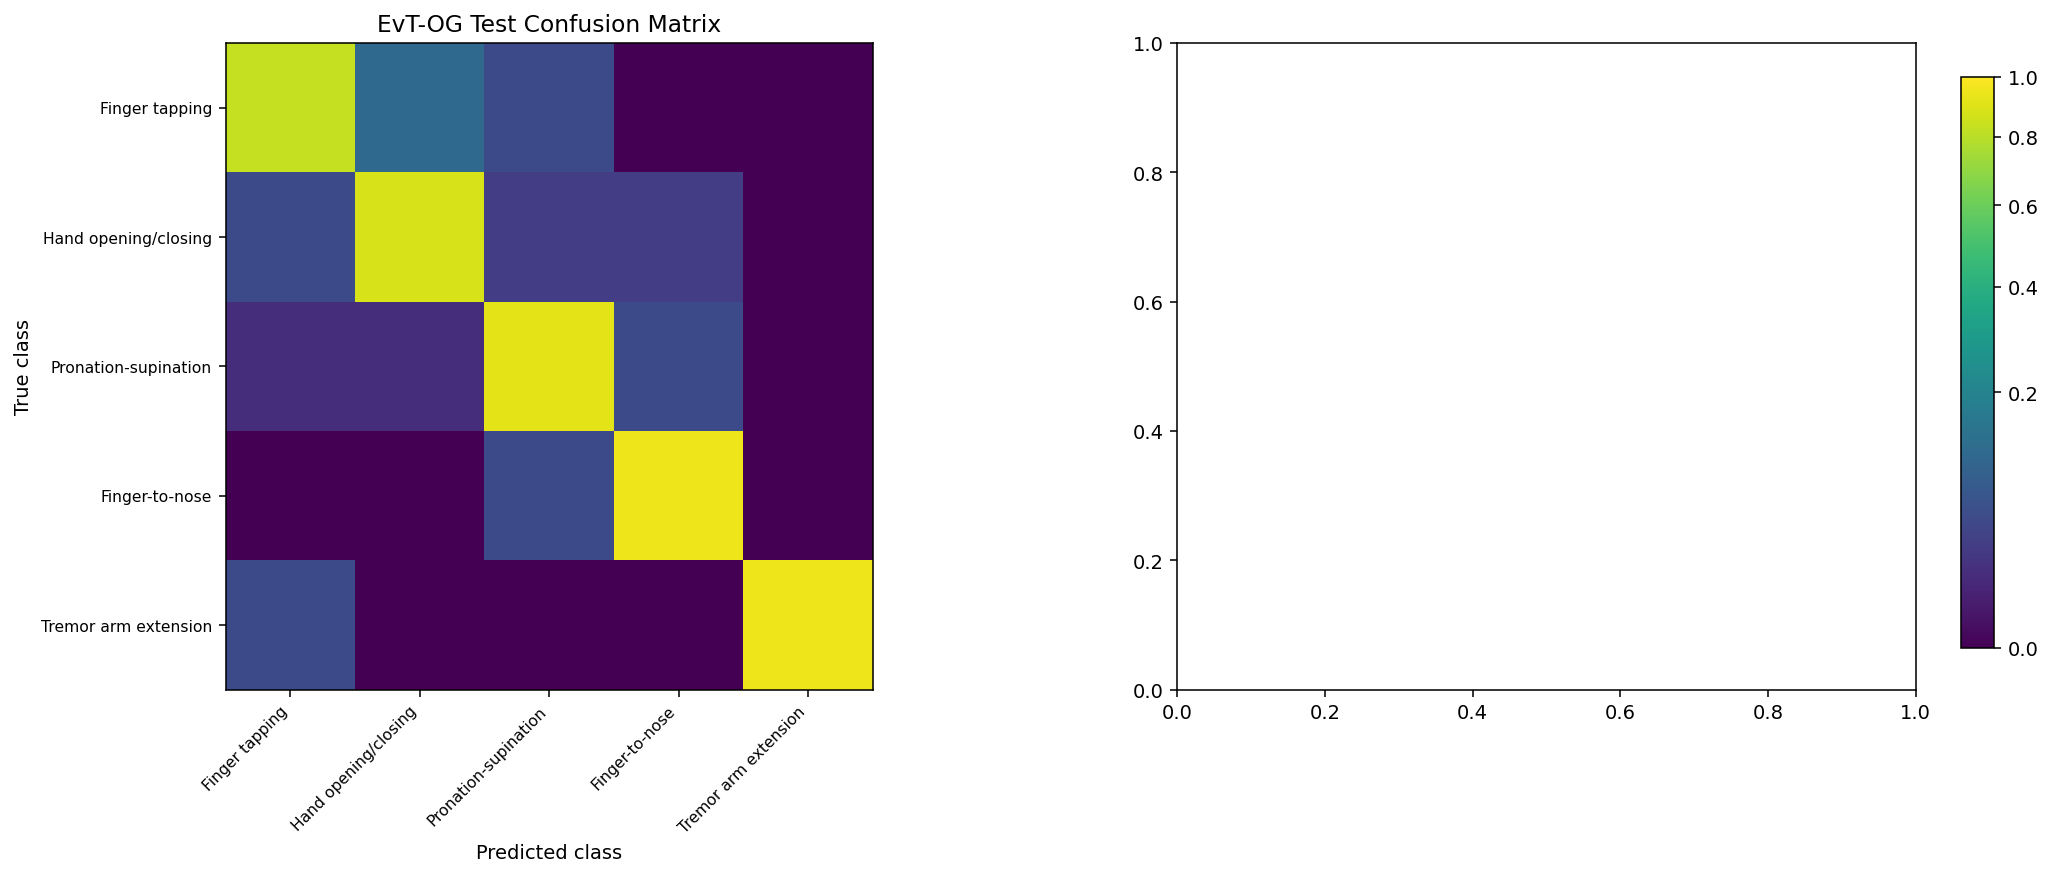

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=140)

cm_df = evt_test_eval['confusion_matrix']
cm_display = cm_df.copy()
cm_display.index = [CLASS_NAME_MAP.get(label, label) for label in cm_display.index]
cm_display.columns = [CLASS_NAME_MAP.get(label, label) for label in cm_display.columns]
im = axes[0].imshow(cm_display.values, cmap='viridis', norm=colors.PowerNorm(gamma=0.5, vmin=0.0, vmax=1.0))
axes[0].set_title('EvT-OG Test Confusion Matrix')
axes[0].set_xticks(range(len(cm_display.columns)))
axes[0].set_yticks(range(len(cm_display.index)))
axes[0].set_xticklabels(cm_display.columns, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(cm_display.index, fontsize=8)
axes[0].set_xlabel('Predicted class')
axes[0].set_ylabel('True class')
axes[0].set_aspect('equal')

# TODO: Timesformer part

fig.subplots_adjust(right=0.90, wspace=0.35)
cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.68])
fig.colorbar(im, cax=cbar_ax)
plt.show() 

## 7. Per-class recall on the shared test split

A confusion matrix is visually useful, but a per-class recall table is easier to cite and discuss in writing. The values below come from the diagonal of the normalized test confusion matrices.


In [8]:
per_class_df = pd.DataFrame({
    'class': DISPLAY_CLASS_NAMES,
    'EvT recall (%)': np.diag(evt_test_eval['confusion_matrix'].values) * 100.0,
    'TimeSformer recall (%)': [None] * len(DISPLAY_CLASS_NAMES),
})
per_class_df['EvT minus TimeSformer (pp)'] = np.nan
display(per_class_df)

# TODO: Timesformer part

,class,EvT recall (%),TimeSformer recall (%),EvT minus TimeSformer (pp)
0,Finger tapping,83.333333,None,NaN
1,Hand opening/closing,88.333333,None,NaN
2,Pronation-supination,91.666667,None,NaN
3,Finger-to-nose,95.000000,None,NaN
4,Tremor arm extension,95.000000,None,NaN


## 8. Resource and efficiency summary

This table keeps only the main resource and efficiency statistics used in the benchmark discussion.

- `Epochs trained` and `Best epoch` are derived from the saved training logs.
- `Time to train` is shown only when a reliable raw training log is available.
- `Peak GPU mem during training (GB)` is shown only when the training logs recorded it.
- `Latency` is reported per processed sample unit used by each model:
  - EvT: per time-window
  - TimeSformer: per clip

In [15]:
evt_best_epoch = int(evt_epoch_metrics.loc[evt_epoch_metrics['val_acc'].astype(float).idxmax(), 'epoch'])
evt_epochs_trained = int(evt_epoch_metrics['epoch'].max())
evt_sample_resolution = '160 x 120'
evt_dataset_root = DEV_ROOT / 'datasets' / 'evt_og' / 'EHWGesture' / 'clean_dataset_frames_12000'
evt_dataset_size_gb = sum(path.stat().st_size for path in evt_dataset_root.rglob('*') if path.is_file()) / (1024 ** 3)

resource_df = pd.DataFrame([
    {
        'Model': 'EvT-OG',
        'Params (M)': evt_test_eval['params_m'],
        'FLOPs (G)': evt_test_eval['flops_g'],
        'Latency on test (ms)': evt_test_eval['latency_ms'],
        'Peak GPU during test (GB)': evt_test_eval['peak_gpu_mem_gb'],
        'Peak GPU during training (GB)': 'NaN',
        'Activated patches': evt_test_eval['activated_patches'],
        'Sample resolution': evt_sample_resolution,
        'Dataset Size (GB)': round(evt_dataset_size_gb, 3),
        'Epochs trained': evt_epochs_trained,
        'Time to train': 'NaN',
        'Best epoch': evt_best_epoch,
    },
])
display(resource_df)

# TODO: Timesformer part


,Model,Params (M),FLOPs (G),Latency on test (ms),Peak GPU during test (GB),Peak GPU during training (GB),Activated patches,Sample resolution,Dataset Size (GB),Epochs trained,Time to train,Best epoch
0,EvT-OG,0.497637,0.113694,0.761677,0.012232,NaN,100.368636,160 x 120,95.349,78,NaN,78


**What each statistic means in practice**

- **Params (M):** how many trainable parameters the model has; a rough measure of model size.
- **FLOPs (G):** how much computation one forward pass needs; higher usually means more compute cost.
- **Latency on test (ms):** how long inference takes on average during test-time evaluation.
- **Peak GPU mem (GB):** the highest GPU memory usage observed.
- **Activated patches:** how many sparse event patches EvT actually processed on average.
- **Sample resolution:** resolution used for the model input.
- **Dataset Size:** size of the dataset after preprocessing.
- **Epochs trained:** how many training epochs the run completed before stopping.
- **Time to train:** the total training time available from the saved logs.
- **Best epoch:** the epoch that produced the best validation checkpoint according to the tracked metric.

## 9. Benchmark interpretation

The notebook now contains the pieces needed for a fair benchmark discussion:

- **shared top-1 and top-5 accuracy/loss** for both models;
- **trainning vs validation curves** for both models;
- **test post-hoc evaluation** for both models;
- **test confusion matrices** for both models;
- **resource and efficiency statistics** for both models.

## Final conclusion

> **Benchmark conclusion.** TODO

> **Accuracy conclusion.** TODO

> **Training and generalization conclusion.** TODO

> **Efficiency conclusion.** TODO

> **Overall thesis takeaway.** TODO

### Notas:

- Top5 acc e loss tão sempre a 1 porque são apenas 5 classes neste dataset então ele acerta sempre 